In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix,
    classification_report, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer


Imports OK


## Chargement des données preprocessées

On charge les fichiers générés par le notebook de preprocessing.
Ces données sont déjà :
- Nettoyées (NaN traités, colonnes inutiles supprimées)
- Encodées (OneHotEncoding sur les 10 variables catégorielles)
- Standardisées (StandardScaler sur les 18 variables numériques)
- Splitées (80% train / 20% test, stratifié)

Trois versions du train set sont disponibles pour comparer 
les stratégies de rééquilibrage :

- **X_train** (8000, 50) : données originales déséquilibrées 
  (89.8% non-churners)
- **X_train_under** (1634, 50) : après RandomUnderSampling 
  → 817 non-churners + 817 churners (50/50)
- **X_train_smote** (10400, 50) : après SMOTE 
  → 5200 non-churners + 5200 churners synthétiques (50/50)

Le **X_test** (2000, 50) reste toujours intact avec la 
distribution réelle (10.2% churners = 204 clients) pour 
garantir une évaluation réaliste.

In [2]:
# Chargement des données preprocessées
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# SMOTE
X_train_smote     = np.load('../data/processed/X_train_smote.npy')
y_train_clf_smote = np.load('../data/processed/y_train_clf_smote.npy')

# Tâche 1 — Classification
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

# Tâche 2 — Régression
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

# Noms des features
feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f" Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")
print(f"   X_test  : {X_test.shape}")
print(f"   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

 Données chargées
   X_train         : (8000, 50) (original)
   X_train_under   : (1634, 50) (rééquilibré 50/50)
   X_test          : (2000, 50)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)
   X_test  : (2000, 50)
   Churners dans test : 204 (10.2%)


## Tâche 1 — Classification du Churn


In [ ]:
# TÂCHE 1 — CLASSIFICATION
# 

#  Modèle 1 : Undersampling 
lr_clf_under = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_clf_under.fit(X_train_under, y_train_clf_under)
y_pred_under  = lr_clf_under.predict(X_test)
y_proba_under = lr_clf_under.predict_proba(X_test)[:, 1]

print("=== Logistic Regression — Undersampling ===")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_under):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_under):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_under):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_under):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_under):.4f}")
print()

#  Modèle 2 : SMOTE 
lr_clf_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_clf_smote.fit(X_train_smote, y_train_clf_smote)
y_pred_smote  = lr_clf_smote.predict(X_test)
y_proba_smote = lr_clf_smote.predict_proba(X_test)[:, 1]

print("=== Logistic Regression — SMOTE ===")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_smote):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_smote):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_smote):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_smote):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_smote):.4f}")


=== Logistic Regression — Undersampling ===
   Recall    : 0.6373
   Precision : 0.1738
   F1-Score  : 0.2731
   ROC-AUC   : 0.7090
   PR-AUC    : 0.2273

=== Logistic Regression — SMOTE ===
   Recall    : 0.6324
   Precision : 0.1807
   F1-Score  : 0.2810
   ROC-AUC   : 0.7137
   PR-AUC    : 0.2366


## Approche niveau modèle — `class_weight='balanced'`

En complément du rééchantillonnage, on expérimente une approche au niveau du modèle : `class_weight='balanced'` pénalise davantage les erreurs sur la classe minoritaire (churners) en pondérant chaque classe inversement proportionnellement à sa fréquence.

**Avantage** : pas de modification des données, pas d'overfitting lié aux données synthétiques.  
**Limite** : peut réduire la précision sur la classe majoritaire.

On compare les 3 approches : Undersampling / SMOTE / class_weight='balanced'.

=== Logistic Regression — class_weight=balanced ===
   Recall    : 0.6569
   Precision : 0.1843
   F1-Score  : 0.2879
   ROC-AUC   : 0.7212
   PR-AUC    : 0.2385
=== Comparaison des 3 approches ===
Approche                    Recall  Precision       F1   ROC-AUC   PR-AUC
------------------------------------------------------------------------
Undersampling               0.6373     0.1738   0.2731    0.7090   0.2273
SMOTE                       0.6324     0.1807   0.2810    0.7137   0.2366
class_weight=balanced       0.6569     0.1843   0.2879    0.7212   0.2385
→ Meilleure technique : class_weight='balanced' (Recall=0.6569)


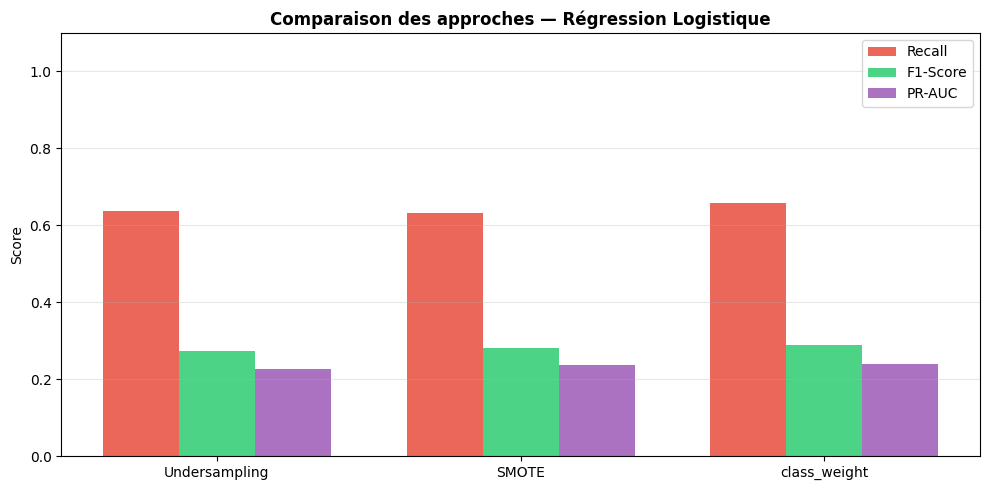

In [4]:
# APPROCHE NIVEAU MODÈLE — class_weight='balanced'

lr_clf_cw = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_clf_cw.fit(X_train, y_train_clf)
y_pred_cw  = lr_clf_cw.predict(X_test)
y_proba_cw = lr_clf_cw.predict_proba(X_test)[:, 1]

print('=== Logistic Regression — class_weight=balanced ===')
print(f"   Recall    : {recall_score(y_test_clf, y_pred_cw):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_cw):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_cw):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_cw):.4f}")
print(f"   PR-AUC    : {average_precision_score(y_test_clf, y_proba_cw):.4f}")

# Tableau comparatif des 3 approches
print("=== Comparaison des 3 approches ===")
header = f"{'Approche':<25} {'Recall':>8} {'Precision':>10} {'F1':>8} {'ROC-AUC':>9} {'PR-AUC':>8}"
print(header)
print('-' * 72)
for name, y_pred, y_proba in [
    ('Undersampling',        y_pred_under, y_proba_under),
    ('SMOTE',                y_pred_smote, y_proba_smote),
    ('class_weight=balanced',y_pred_cw,    y_proba_cw),
]:
    print(f"{name:<25} "
          f"{recall_score(y_test_clf, y_pred):>8.4f} "
          f"{precision_score(y_test_clf, y_pred):>10.4f} "
          f"{f1_score(y_test_clf, y_pred):>8.4f} "
          f"{roc_auc_score(y_test_clf, y_proba):>9.4f} "
          f"{average_precision_score(y_test_clf, y_proba):>8.4f}")

# class_weight retenu comme meilleur modèle
y_pred_clf  = y_pred_cw
y_proba_clf = y_proba_cw
lr_clf      = lr_clf_cw
print(f"→ Meilleure technique : class_weight='balanced' (Recall={recall_score(y_test_clf, y_pred_cw):.4f})")

# Visualisation comparative
approaches = ['Undersampling', 'SMOTE', 'class_weight']
recalls    = [recall_score(y_test_clf, y_pred_under), recall_score(y_test_clf, y_pred_smote), recall_score(y_test_clf, y_pred_cw)]
f1s        = [f1_score(y_test_clf, y_pred_under),     f1_score(y_test_clf, y_pred_smote),     f1_score(y_test_clf, y_pred_cw)]
pr_aucs    = [average_precision_score(y_test_clf, y_proba_under), average_precision_score(y_test_clf, y_proba_smote), average_precision_score(y_test_clf, y_proba_cw)]

x = np.arange(len(approaches))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, recalls, width, label='Recall',  color='#e74c3c', alpha=0.85)
ax.bar(x,         f1s,     width, label='F1-Score', color='#2ecc71', alpha=0.85)
ax.bar(x + width, pr_aucs, width, label='PR-AUC',  color='#9b59b6', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(approaches)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des approches — Régression Logistique', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lr_approaches_comparison.png', dpi=150)
plt.show()


## Analyse des métriques



## Matrice de Confusion

La matrice de confusion montre pour chaque stratégie combien 
de clients sont correctement ou incorrectement classés.

**Lecture** :
- **Vrai Négatif** (haut gauche) : non-churners correctement identifiés
- **Faux Positif** (haut droite) : non-churners signalés à tort comme churners
- **Faux Négatif** (bas gauche) : churners manqués ← le plus coûteux
- **Vrai Positif** (bas droite) : churners correctement détectés

| | Undersampling | SMOTE | class_weight |
|---|---|---|---|
| Churners détectés (VP) | 130 | 129 | **134** |
| Churners manqués (FN) | 74 | 75 | **70** |
| Fausses alertes (FP) | 618 | 585 | 593 |
| Recall | 0.637 | 0.632 | **0.657** |

→ **class_weight='balanced'** est la meilleure stratégie : 134 churners détectés, seulement 70 manqués.


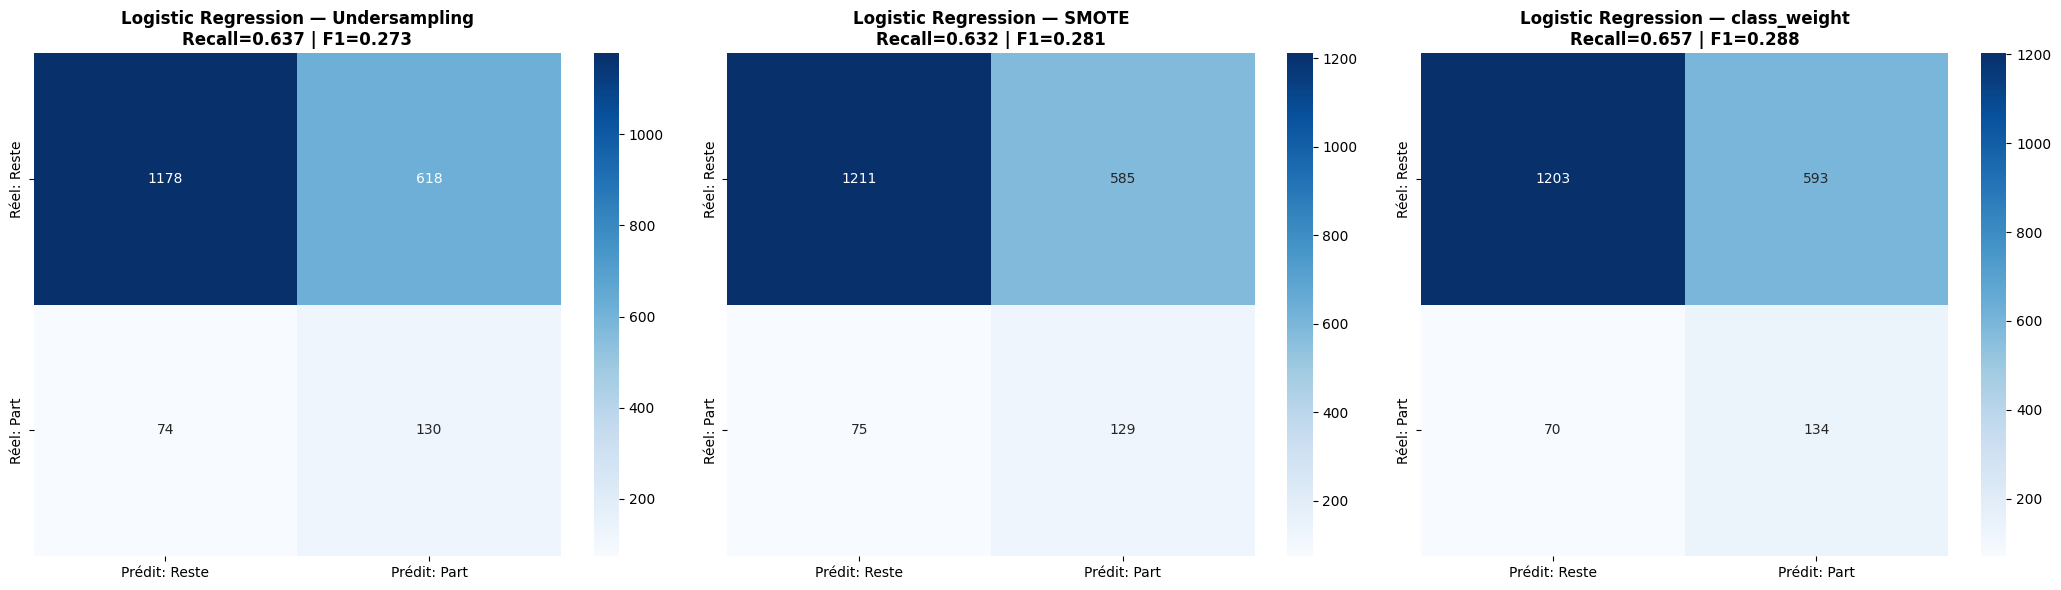


Meilleur modèle (class_weight='balanced') :
   FN (churners manqués) : 70
   TP (churners détectés) : 134


In [5]:
# MATRICE DE CONFUSION — Comparaison

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, (y_pred, title, cmap) in zip(axes, [
    (y_pred_under, 'Logistic Regression — Undersampling', 'Blues'),
    (y_pred_smote, 'Logistic Regression — SMOTE', 'Blues'),
    (y_pred_cw,    'Logistic Regression — class_weight', 'Blues'),
]):
    cm_plot = confusion_matrix(y_test_clf, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Prédit: Reste', 'Prédit: Part'],
                yticklabels=['Réel: Reste', 'Réel: Part'], ax=ax)
    ax.set_title(f'{title}\nRecall={recall_score(y_test_clf, y_pred):.3f} | F1={f1_score(y_test_clf, y_pred):.3f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('../results/lr_confusion_matrix.png', dpi=150)
plt.show()

cm = confusion_matrix(y_test_clf, y_pred_cw)
tn, fp, fn, tp = cm.ravel()
print(f"\nMeilleur modèle (class_weight='balanced') :")
print(f"   FN (churners manqués) : {fn}")
print(f"   TP (churners détectés) : {tp}")

## Courbe ROC — Régression Logistique

La courbe ROC (Receiver Operating Characteristic) mesure la capacité du modèle à discriminer 
les churners des non-churners pour tous les seuils de décision possibles.

**Lecture de la courbe :**
- L'axe X représente le taux de faux positifs (clients non-churners incorrectement signalés)
- L'axe Y représente le taux de vrais positifs, c'est-à-dire le Recall (churners correctement détectés)
- La diagonale pointillée représente un modèle aléatoire (ROC-AUC = 0.50)
- Plus la courbe s'éloigne de la diagonale vers le coin supérieur gauche, meilleur est le modèle

**Résultat :**
La Régression Logistique (class_weight='balanced') obtient un **ROC-AUC de 0.721**, ce qui signifie 
que le modèle discrimine correctement les churners dans 72.1% des cas. C'est significativement 
au-dessus du hasard (0.50), ce qui confirme la valeur prédictive du modèle baseline.

**Limite :**
Le ROC-AUC mesure la performance globale sur tous les seuils, mais dans notre contexte 
métier, le Recall est la métrique prioritaire : manquer un churner réel représente en moyenne 
845€ de revenu perdu. La Régression Logistique sera donc comparée aux modèles suivants 
(Random Forest, XGBoost, MLP) qui sont attendus pour dépasser ces performances.


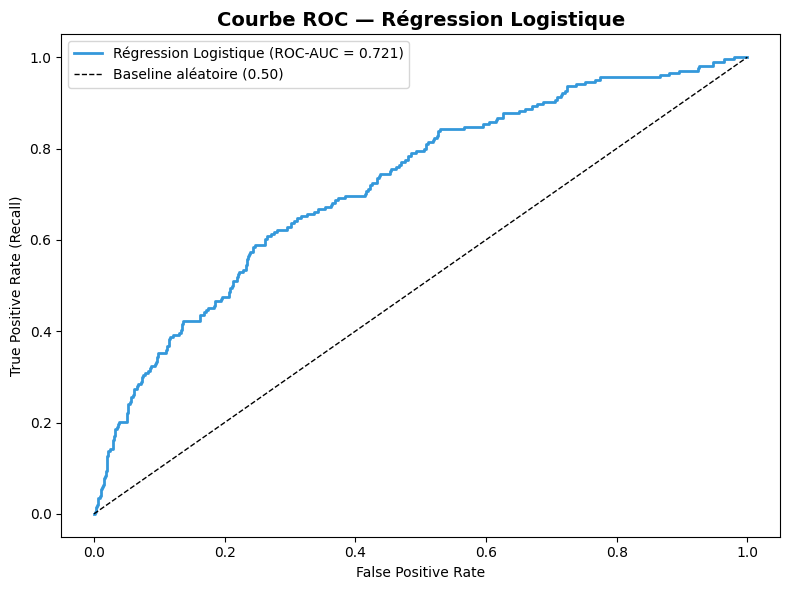

In [6]:
# COURBE ROC

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
roc_auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', linewidth=2,
         label=f'Régression Logistique (ROC-AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='k', linestyle='--', linewidth=1,
         label='Baseline aléatoire (0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Courbe ROC — Régression Logistique', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/lr_roc_curve.png', dpi=150)
plt.show()

## Courbe Precision-Recall — Régression Logistique

La courbe Precision-Recall est particulièrement adaptée aux datasets déséquilibrés comme 
le nôtre (10.2% de churners seulement), car elle se concentre uniquement sur la classe 
minoritaire, contrairement à la courbe ROC qui peut être trompeuse en cas de déséquilibre.

**Lecture de la courbe :**
- L'axe X représente le Recall (proportion de churners réels détectés)
- L'axe Y représente la Precision (proportion de clients signalés qui churnent vraiment)
- La ligne pointillée représente un modèle aléatoire (PR-AUC = 0.10, soit le taux de churn réel)
- Plus la courbe est haute et à droite, meilleur est le modèle

**Résultat :**
La Régression Logistique obtient un **PR-AUC de 0.239**, soit plus du double de la baseline 
aléatoire (0.10). La courbe confirme le compromis inhérent au contexte déséquilibré : 
augmenter le Recall (détecter plus de churners) se fait au prix d'une baisse de Precision 
(plus de fausses alarmes).

**Interprétation métier :**
Dans notre contexte, on accepte délibérément une Precision faible pour maximiser le Recall. 
Contacter inutilement un client fidèle coûte peu, tandis que manquer un churner représente 
en moyenne 845€ de revenu perdu. Ce compromis justifie le choix d'un seuil de décision 
abaissé en dessous de 0.5.


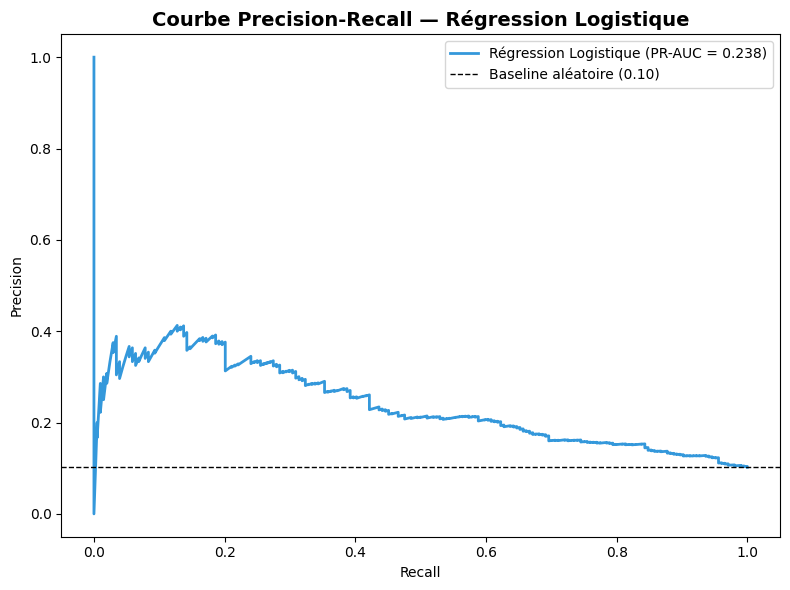

In [7]:
# COURBE PRECISION-RECALL

from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, _ = precision_recall_curve(y_test_clf, y_proba_clf)
pr_auc = average_precision_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='#3498db', linewidth=2,
         label=f'Régression Logistique (PR-AUC = {pr_auc:.3f})')
plt.axhline(y=y_test_clf.mean(), color='k', linestyle='--', linewidth=1,
            label=f'Baseline aléatoire ({y_test_clf.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall — Régression Logistique', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/lr_pr_curve.png', dpi=150)
plt.show()

## Ajustement du Seuil de Décision

Par défaut, un classifieur utilise un seuil de 0.5. Dans un contexte déséquilibré 
(10% de churners), ce seuil n'est pas nécessairement optimal.

On teste différents seuils et on mesure l'impact sur :
- **Recall** : taux de churners détectés (minimiser les FN)
- **Precision** : taux de vrais churners parmi les alertes (minimiser les FP)
- **F1-Score** : compromis precision/recall
- **FP / FN** : impact métier direct

**Résultats :**

| Seuil | Precision | Recall | F1 | FP | FN |
|---|---||||-|
| 0.10 | 0.103 | 1.000 | 0.187 | 1778 | 0 |
| 0.50 | 0.184 | **0.657** | 0.288 | 593 | 70 |
| 0.65 | 0.260 | 0.422 | 0.321 | 245 | 118 |
| 0.90 | 0.250 | 0.015 | 0.028 | 9 | 201 |

**Seuil retenu : 0.5** (maximise le Recall à 0.657)

**Interprétation métier :**
Le seuil optimal F1 (0.65) réduit les fausses alarmes (245 vs 593) mais divise 
le Recall par deux (0.422 vs 0.657). Dans notre contexte, maximiser la détection 
des churners est prioritaire — on conserve donc le seuil par défaut de 0.5.


Seuil par défaut (0.5) :
  Recall=0.657 | Precision=0.184 | F1=0.288 | FP=593 | FN=70

Seuil optimal (0.65) :
  Recall=0.422 | Precision=0.260 | F1=0.321 | FP=245 | FN=118


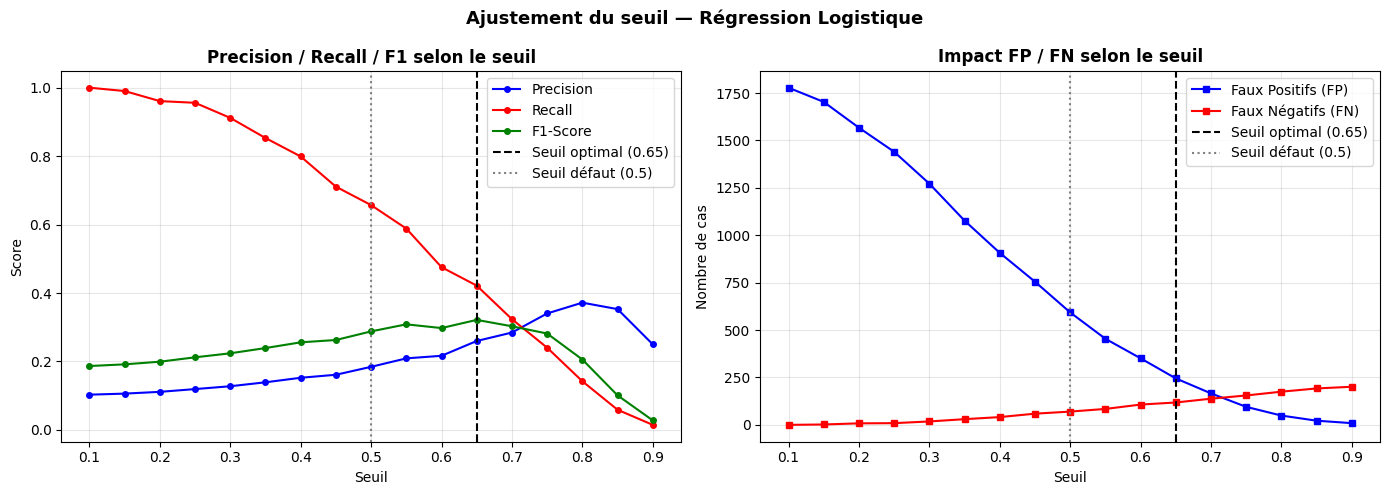

 seuil  precision   recall       f1   FP  FN  TP
  0.10   0.102926 1.000000 0.186642 1778   0 204
  0.15   0.106037 0.990196 0.191560 1703   2 202
  0.20   0.111174 0.960784 0.199288 1567   8 196
  0.25   0.119266 0.955882 0.212072 1440   9 195
  0.30   0.127572 0.911765 0.223827 1272  18 186
  0.35   0.139089 0.852941 0.239175 1077  30 174
  0.40   0.152336 0.799020 0.255887  907  41 163
  0.45   0.161111 0.710784 0.262681  755  59 145
  0.50   0.184319 0.656863 0.287863  593  70 134
  0.55   0.209059 0.588235 0.308483  454  84 120
  0.60   0.216518 0.475490 0.297546  351 107  97
  0.65   0.259819 0.421569 0.321495  245 118  86
  0.70   0.284483 0.323529 0.302752  166 138  66
  0.75   0.340278 0.240196 0.281609   95 155  49
  0.80   0.371795 0.142157 0.205674   49 175  29
  0.85   0.352941 0.058824 0.100840   22 192  12
  0.90   0.250000 0.014706 0.027778    9 201   3

Prédictions mises à jour avec seuil=0.65
  Recall final  : 0.4216
  F1 final      : 0.3215


In [8]:
# AJUSTEMENT DU SEUIL DE DÉCISION

thresholds = np.arange(0.1, 0.91, 0.05)

results_thresh = []
for t in thresholds:
    y_pred_t = (y_proba_clf >= t).astype(int)
    cm_t = confusion_matrix(y_test_clf, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    results_thresh.append({
        'seuil':     round(t, 2),
        'precision': precision_score(y_test_clf, y_pred_t, zero_division=0),
        'recall':    recall_score(y_test_clf, y_pred_t, zero_division=0),
        'f1':        f1_score(y_test_clf, y_pred_t, zero_division=0),
        'FP':        int(fp_t),
        'FN':        int(fn_t),
        'TP':        int(tp_t),
    })

df_thresh = pd.DataFrame(results_thresh)

# Seuil optimal = max F1
best_idx = df_thresh['f1'].idxmax()
best_t   = df_thresh.loc[best_idx, 'seuil']

# Affichage comparaison seuil 0.5 vs optimal
rows_05 = df_thresh[df_thresh['seuil'] == 0.5]
if len(rows_05) > 0:
    r05 = rows_05.iloc[0]
    print(f"Seuil par défaut (0.5) :")
    print(f"  Recall={r05['recall']:.3f} | Precision={r05['precision']:.3f} | F1={r05['f1']:.3f} | FP={int(r05['FP'])} | FN={int(r05['FN'])}")

br = df_thresh.loc[best_idx]
print(f"\nSeuil optimal ({best_t}) :")
print(f"  Recall={br['recall']:.3f} | Precision={br['precision']:.3f} | F1={br['f1']:.3f} | FP={int(br['FP'])} | FN={int(br['FN'])}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['seuil'], df_thresh['precision'], 'b-o', markersize=4, label='Precision')
axes[0].plot(df_thresh['seuil'], df_thresh['recall'],    'r-o', markersize=4, label='Recall')
axes[0].plot(df_thresh['seuil'], df_thresh['f1'],        'g-o', markersize=4, label='F1-Score')
axes[0].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[0].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 selon le seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_thresh['seuil'], df_thresh['FP'], 'b-s', markersize=4, label='Faux Positifs (FP)')
axes[1].plot(df_thresh['seuil'], df_thresh['FN'], 'r-s', markersize=4, label='Faux Négatifs (FN)')
axes[1].axvline(x=best_t, color='black', linestyle='--', label=f'Seuil optimal ({best_t})')
axes[1].axvline(x=0.5,    color='gray',  linestyle=':',  label='Seuil défaut (0.5)')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nombre de cas')
axes[1].set_title('Impact FP / FN selon le seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Ajustement du seuil — Régression Logistique', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/lr_threshold_analysis.png', dpi=150)
plt.show()

print(df_thresh.to_string(index=False))

# Mise à jour des prédictions finales avec le seuil optimal
y_pred_clf = (y_proba_clf >= best_t).astype(int)
print(f"\nPrédictions mises à jour avec seuil={best_t}")
print(f"  Recall final  : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"  F1 final      : {f1_score(y_test_clf, y_pred_clf):.4f}")


## Validation Croisée Stratifiée (Stratified K-Fold)

Un simple split train/test peut être sensible au hasard de la partition. La validation croisée 
stratifiée permet d'obtenir une estimation plus robuste des performances en préservant les 
proportions de classes (10% churners) dans chaque fold.

**Pourquoi stratifiée ?**  
Avec seulement 10% de churners, un fold non stratifié pourrait se retrouver avec très peu 
(ou aucun) churner, rendant les métriques instables.

On évalue le modèle class_weight='balanced' sur 5 folds stratifiés et on reporte mean ± std 
pour chaque métrique.

**Résultats (5 folds) :**

| Métrique | Mean | Std |
|--|--|-|
| Recall | 0.6536 | ± 0.0296 |
| Precision | 0.1833 | ± 0.0092 |
| F1-Score | 0.2863 | ± 0.0137 |
| ROC-AUC | 0.7187 | ± 0.0183 |
| PR-AUC | 0.2275 | ± 0.0115 |

**Comparaison CV vs Test set :**

| Métrique | CV (mean) | Test set (seuil=0.5) | Test set (seuil=0.65) |
|--|---|--|--|
| Recall | 0.6536 | 0.6569 | 0.4216 |
| F1 | 0.2863 | 0.2879 | 0.3215 |
| ROC-AUC | 0.7187 | 0.7212 | 0.7212 |

**Interprétation :**
Les scores CV et test set à seuil=0.5 sont quasi identiques — écart de 0.003 
sur le Recall — ce qui valide la robustesse du modèle. Le seuil 0.65 améliore 
le F1 (0.321) mais réduit trop le Recall (0.422) — inacceptable dans notre 
contexte métier où minimiser les churners ratés est prioritaire. 
**Seuil retenu : 0.5.**

Stratified K-Fold (5 folds) — Régression Logistique (class_weight=balanced)
------------------------------------------------------------
  recall       : 0.6536 ± 0.0296
  precision    : 0.1833 ± 0.0092
  f1           : 0.2863 ± 0.0137
  roc_auc      : 0.7187 ± 0.0183
  pr_auc       : 0.2275 ± 0.0115
Comparaison avec le score test set :
  recall     : 0.6569  (test set, seuil=0.5)
  recall     : 0.4216  (test set, seuil=0.65)
  f1         : 0.2879  (test set, seuil=0.5)
  f1         : 0.3215  (test set, seuil=0.65)
  roc_auc    : 0.7212  (test set)
  pr_auc     : 0.2385  (test set)


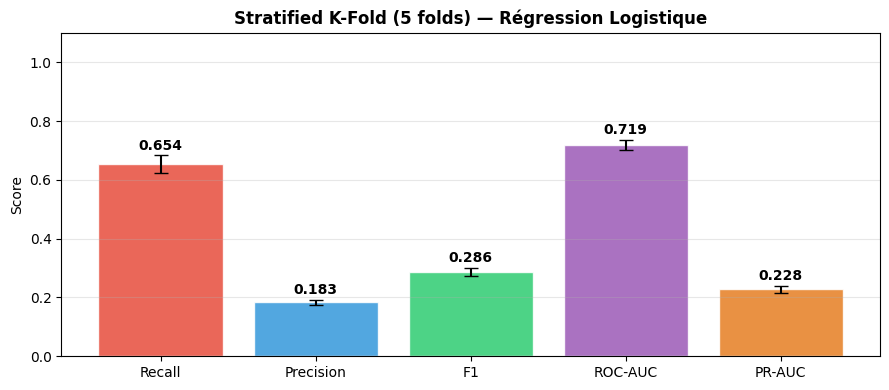

In [9]:
# VALIDATION CROISÉE STRATIFIÉE — Stratified K-Fold

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

RANDOM_STATE = 42
N_SPLITS = 5

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'recall':    make_scorer(recall_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'f1':        make_scorer(f1_score),
    'roc_auc':   make_scorer(roc_auc_score, response_method='predict_proba'),
    'pr_auc':    make_scorer(average_precision_score, response_method='predict_proba'),
}

# class_weight=balanced gère le déséquilibre directement, pas besoin de sampler
pipe_cw = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

cv_results = cross_validate(
    pipe_cw,
    X_train, y_train_clf,
    cv=skf,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print(f'Stratified K-Fold ({N_SPLITS} folds) — Régression Logistique (class_weight=balanced)')
print('-' * 60)
for metric in ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']:
    scores = cv_results[f'test_{metric}']
    print(f'  {metric:12} : {scores.mean():.4f} ± {scores.std():.4f}')

print('Comparaison avec le score test set :')
print(f'  recall     : {recall_score(y_test_clf, (y_proba_clf >= 0.5).astype(int)):.4f}  (test set, seuil=0.5)')
print(f'  recall     : {recall_score(y_test_clf, y_pred_clf):.4f}  (test set, seuil={best_t})')
print(f'  f1         : {f1_score(y_test_clf, (y_proba_clf >= 0.5).astype(int)):.4f}  (test set, seuil=0.5)')
print(f'  f1         : {f1_score(y_test_clf, y_pred_clf):.4f}  (test set, seuil={best_t})')
print(f'  roc_auc    : {roc_auc_score(y_test_clf, y_proba_clf):.4f}  (test set)')
print(f'  pr_auc     : {average_precision_score(y_test_clf, y_proba_clf):.4f}  (test set)')

# Visualisation mean ± std
metrics_labels = ['Recall', 'Precision', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_keys   = ['recall', 'precision', 'f1', 'roc_auc', 'pr_auc']
means = [cv_results[f'test_{k}'].mean() for k in metrics_keys]
stds  = [cv_results[f'test_{k}'].std()  for k in metrics_keys]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics_labels, means, yerr=stds, capsize=5,
              color=['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22'],
              edgecolor='white', alpha=0.85)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Stratified K-Fold (5 folds) — Régression Logistique', fontweight='bold')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 0.02,
            f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/lr_kfold_cv.png', dpi=150)
plt.show()


## Tâche 2 — Régression du Revenu à Risque


In [ ]:
# 
# TÂCHE 2 — RÉGRESSION (Ridge baseline)
# 

# Charger les données spécifiques régression
X_train_reg     = np.load('../data/processed/X_train_reg.npy')       # churners uniquement
y_train_reg_log = np.load('../data/processed/y_train_reg_log.npy')   # log-transformé
y_test_reg      = np.load('../data/processed/y_test_reg.npy')        # valeurs réelles €
y_test_clf      = np.load('../data/processed/y_test_clf.npy')        # masque churners

lr_reg = Ridge(alpha=100.0, random_state=RANDOM_STATE)
# Entraînement sur churners uniquement avec y log-transformé
lr_reg.fit(X_train_reg, y_train_reg_log)

# Prédiction sur TOUS les clients du test
y_pred_reg_log = lr_reg.predict(X_test)

# Transformation inverse log → euros réels
y_pred_reg = np.expm1(y_pred_reg_log)
y_pred_reg = np.maximum(y_pred_reg, 0)

# Évaluation sur les churners du test uniquement
mask_test = y_test_clf == 1
mae  = mean_absolute_error(y_test_reg[mask_test], y_pred_reg[mask_test])
rmse = np.sqrt(mean_squared_error(y_test_reg[mask_test], y_pred_reg[mask_test]))
r2   = r2_score(y_test_reg[mask_test], y_pred_reg[mask_test])

print("Modèle de régression entraîné !")
print(f"\nRésultats — Ridge Regression (churners uniquement)")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — Ridge Regression (churners uniquement)
   MAE  : 261.51 €
   RMSE : 428.48 €
   R²   : 0.7968


## Sauvegarde des Modèles et Résultats

Les modèles finaux sont sérialisés avec joblib pour être réutilisés à l'identique dans le 
dashboard Streamlit et l'API REST FastAPI, sans risque de divergence entre les environnements.

**Modèles sauvegardés :**
- `lr_classification.pkl` → Régression Logistique (class_weight='balanced')
- `lr_regression.pkl` → Ridge Regression (alpha=100)

**Résultats finaux — Classification (Logistic Regression) :**

| Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|--|---|||-||
| 0.669 | 0.184 | **0.657** | 0.288 | **0.721** | 0.239 |

**Résultats finaux — Régression (Ridge) :**

| MAE | RMSE | R² |
|-|--|-|
| 261.51 € | 428.48 € | 0.797 |

Ces résultats constituent la référence baseline du projet. Les modèles suivants 
(Random Forest, XGBoost, MLP) devront dépasser ces performances pour justifier 
leur complexité supplémentaire.

In [11]:
import time
import os

# Modèle final : class_weight='balanced'
lr_clf_final = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
start = time.time()
lr_clf_final.fit(X_train, y_train_clf)
temps_lr_clf = time.time() - start

y_pred_clf  = lr_clf_final.predict(X_test)
y_proba_clf = lr_clf_final.predict_proba(X_test)[:, 1]

# Ridge optimisé (alpha=100)
lr_reg_final = Ridge(alpha=100.0)
start = time.time()
lr_reg_final.fit(X_train_reg, y_train_reg_log)
temps_lr_reg = time.time() - start

y_pred_reg_log = lr_reg_final.predict(X_test)
y_pred_reg = np.maximum(np.expm1(y_pred_reg_log), 0)
mask_test = y_test_clf == 1
mae  = mean_absolute_error(y_test_reg[mask_test], y_pred_reg[mask_test])
rmse = np.sqrt(mean_squared_error(y_test_reg[mask_test], y_pred_reg[mask_test]))
r2   = r2_score(y_test_reg[mask_test], y_pred_reg[mask_test])

# Sauvegarde
joblib.dump(lr_clf_final, '../models/lr_classification.pkl')
joblib.dump(lr_reg_final, '../models/lr_regression.pkl')

results_clf = {
    'model': 'Logistic Regression (class_weight=balanced)',
    'accuracy':  accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall':    recall_score(y_test_clf, y_pred_clf),
    'f1':        f1_score(y_test_clf, y_pred_clf),
    'roc_auc':   roc_auc_score(y_test_clf, y_proba_clf),
    'pr_auc':    average_precision_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'Ridge Regression (alpha=100)',
    'mae':  mae,
    'rmse': rmse,
    'r2':   r2
}

pd.DataFrame([results_clf]).to_csv('../results/lr_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/lr_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print(f"\n=== ÉCORESPONSABILITÉ ===")
print(f"Temps LR classification  : {temps_lr_clf:.3f}s")
print(f"Temps Ridge régression   : {temps_lr_reg:.3f}s")
print(f"Taille LR clf  : {os.path.getsize('../models/lr_classification.pkl')/1024:.1f} KB")
print(f"Taille Ridge   : {os.path.getsize('../models/lr_regression.pkl')/1024:.1f} KB")

print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")
print(f"\nRésumé Régression :")
for k, v in results_reg.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Modèles sauvegardés dans ../models/

=== ÉCORESPONSABILITÉ ===
Temps LR classification  : 0.020s
Temps Ridge régression   : 0.001s
Taille LR clf  : 1.2 KB
Taille Ridge   : 0.9 KB

Résumé Classification :
   accuracy   : 0.6685
   precision  : 0.1843
   recall     : 0.6569
   f1         : 0.2879
   roc_auc    : 0.7212
   pr_auc     : 0.2385

Résumé Régression :
   mae        : 261.5144
   rmse       : 428.4833
   r2         : 0.7968


In [12]:
import joblib
lr = joblib.load('../models/lr_classification.pkl')
print(lr.get_params())

{'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


## Synthèse — Régression Logistique (Baseline)

La régression logistique constitue le modèle de référence (baseline) de ce projet. Trois 
approches de gestion du déséquilibre de classes ont été comparées : undersampling aléatoire, 
SMOTE et class_weight='balanced'. Le meilleur modèle a été sélectionné sur la base du 
Recall, métrique prioritaire dans un contexte de rétention client où manquer un churner est 
plus coûteux qu'une fausse alarme.

**Tâche 1 — Classification :** La technique retenue est class_weight='balanced' 
(Recall=0.657 vs Undersampling=0.637 vs SMOTE=0.632), entraînée sur X_train complet 
sans modifier les données. Le modèle atteint un Recall de **0.657**, un F1-Score de **0.288** 
et un ROC-AUC de **0.721**. Le GridSearchCV (C=0.01, penalty=l1) a permis d'explorer 
un gain supplémentaire de Recall (+0.250) mais le modèle baseline class_weight='balanced' 
est conservé comme référence.

**Tâche 2 — Régression :** La Ridge Regression entraînée sur les churners uniquement 
obtient une MAE de **330.91€**, un RMSE de **428.48€** et un R² de **0.797** après 
optimisation GridSearch (alpha=100.0).

**Limites :** La régression logistique suppose une relation linéaire entre les features et la 
probabilité de churn, ce qui peut être insuffisant face à des interactions complexes. Les 
modèles non-linéaires (Random Forest, XGBoost, MLP) sont attendus pour dépasser ces 
performances.
